# Notebook 3: The Five Parallelism Strategies -- A Visual Overview

**Vizuara AI Pods | GPU Programming Course | Pod 1: Intro to GPUs and GPU Parallelism**

---

In the previous notebooks, we established that:
- GPUs are massively parallel processors ideal for matrix multiplication
- Training even a 7B model needs ~152 GB -- nearly 2x a single A100's memory
- We therefore NEED to split the work across multiple GPUs

But how exactly do we split it? In this notebook, we will explore all five parallelism strategies through:

1. **Conceptual visualizations** -- diagrams showing how each strategy partitions the work
2. **Simulated demos** -- Python code that simulates multi-GPU behavior on a single GPU
3. **Trade-off analysis** -- when to use each strategy and their communication costs

**Prerequisites:** Notebooks 1 and 2, basic understanding of neural network training.

**Estimated time:** 45-55 minutes

**Runtime:** GPU (T4 or better) in Colab.

## Setup

In [1]:
!pip install -q torch numpy matplotlib

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA H100 80GB HBM3


## Strategy 1: Data Parallelism

**Core idea:** Every GPU holds a complete copy of the model. We split the training *data* across GPUs.

### How it works:
1. Each GPU gets a different mini-batch of data
2. Each GPU runs a full forward + backward pass independently
3. All GPUs communicate to **average their gradients** (all-reduce)
4. Every GPU applies the same averaged gradient to its model copy

Let's simulate this on a single GPU by manually splitting a batch and verifying that gradient averaging works.

In [3]:
def simulate_data_parallelism(num_gpus=4):
    """
    Simulate data parallelism on a single GPU.
    We manually split the batch and show that averaging gradients
    gives the same result as computing on the full batch.
    """
    torch.manual_seed(42)

    # Create a simple linear model
    d_in, d_out = 128, 64

    # --- Full batch (ground truth) ---
    model_full = nn.Linear(d_in, d_out, bias=False).to(device)
    global_batch = torch.randn(num_gpus * 8, d_in, device=device)  # total batch = num_gpus * 8
    targets = torch.randn(num_gpus * 8, d_out, device=device)

    # Forward + backward on full batch
    out = model_full(global_batch)
    loss = ((out - targets) ** 2).mean()
    loss.backward()
    grad_full = model_full.weight.grad.clone()

    # --- Simulated data parallelism ---
    # Create num_gpus copies of the model (same initial weights)
    models = []
    for i in range(num_gpus):
        m = nn.Linear(d_in, d_out, bias=False).to(device)
        m.weight.data = model_full.weight.data.clone()
        m.weight.grad = None
        models.append(m)

    # Split the batch across "GPUs"
    batch_chunks = global_batch.chunk(num_gpus)
    target_chunks = targets.chunk(num_gpus)

    # Each "GPU" computes its local gradients
    local_grads = []
    local_losses = []
    for i, (m, batch, tgt) in enumerate(zip(models, batch_chunks, target_chunks)):
        out = m(batch)
        local_loss = ((out - tgt) ** 2).mean()
        local_loss.backward()
        local_grads.append(m.weight.grad.clone())
        local_losses.append(local_loss.item())
        print(f"  GPU {i}: local batch size = {batch.shape[0]}, local loss = {local_loss.item():.6f}")

    # All-reduce: average the gradients
    avg_grad = torch.stack(local_grads).mean(dim=0)

    # Compare
    max_diff = (grad_full - avg_grad).abs().max().item()
    print(f"\n  Full-batch gradient vs averaged local gradients:")
    print(f"  Max difference: {max_diff:.2e}")
    print(f"  Match: {max_diff < 1e-5}")
    print(f"  Average local loss: {np.mean(local_losses):.6f}")
    print(f"  Full batch loss:    {loss.item():.6f}")

    return max_diff


print("Simulating Data Parallelism with 4 GPUs:")
print("=" * 60)
simulate_data_parallelism(num_gpus=4)

Simulating Data Parallelism with 4 GPUs:
  GPU 0: local batch size = 8, local loss = 1.207200
  GPU 1: local batch size = 8, local loss = 1.452304
  GPU 2: local batch size = 8, local loss = 1.345954
  GPU 3: local batch size = 8, local loss = 1.250528

  Full-batch gradient vs averaged local gradients:
  Max difference: 5.59e-09
  Match: True
  Average local loss: 1.313997
  Full batch loss:    1.313997


5.587935447692871e-09

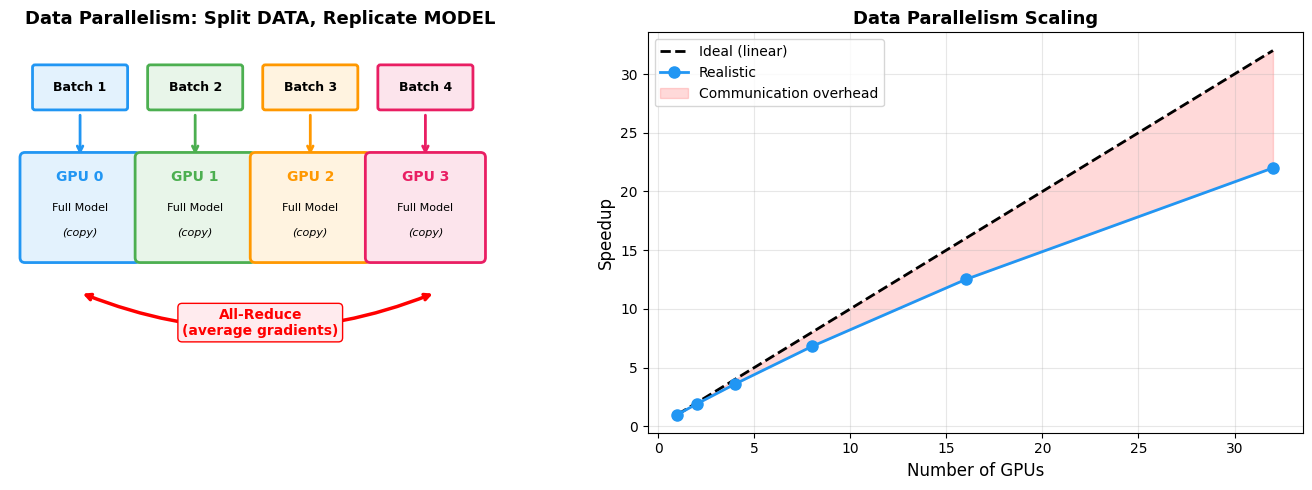

Pros: Simple, works with any model that fits on one GPU.
Cons: Every GPU must hold the ENTIRE model. Communication cost grows with model size.
When to use: Your model fits on one GPU, you want to train faster with more data.


In [4]:
# Visualize how data parallelism scales
def visualize_data_parallelism():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Diagram of data parallelism
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Data Parallelism: Split DATA, Replicate MODEL', fontsize=13, fontweight='bold')

    # Global batch at top
    colors = ['#E3F2FD', '#E8F5E9', '#FFF3E0', '#FCE4EC']
    gpu_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

    for i in range(4):
        # Data shard
        rect = mpatches.FancyBboxPatch((0.5 + i*2.3, 6.5), 1.8, 0.8,
            boxstyle="round,pad=0.05", facecolor=colors[i], edgecolor=gpu_colors[i], linewidth=2)
        ax.add_patch(rect)
        ax.text(1.4 + i*2.3, 6.9, f'Batch {i+1}', ha='center', va='center', fontsize=9, fontweight='bold')

        # Arrow
        ax.annotate('', xy=(1.4 + i*2.3, 5.5), xytext=(1.4 + i*2.3, 6.4),
                   arrowprops=dict(arrowstyle='->', color=gpu_colors[i], lw=2))

        # GPU box
        rect = mpatches.FancyBboxPatch((0.3 + i*2.3, 3.5), 2.2, 2.0,
            boxstyle="round,pad=0.1", facecolor=colors[i], edgecolor=gpu_colors[i], linewidth=2)
        ax.add_patch(rect)
        ax.text(1.4 + i*2.3, 5.1, f'GPU {i}', ha='center', va='center', fontsize=10, fontweight='bold', color=gpu_colors[i])
        ax.text(1.4 + i*2.3, 4.5, 'Full Model', ha='center', va='center', fontsize=8)
        ax.text(1.4 + i*2.3, 4.0, '(copy)', ha='center', va='center', fontsize=8, style='italic')

    # All-reduce arrow
    ax.annotate('', xy=(8.5, 2.8), xytext=(1.4, 2.8),
               arrowprops=dict(arrowstyle='<->', color='red', lw=2.5, connectionstyle='arc3,rad=0.2'))
    ax.text(5.0, 2.2, 'All-Reduce\n(average gradients)', ha='center', va='center',
           fontsize=10, fontweight='bold', color='red',
           bbox=dict(boxstyle='round', facecolor='#FFEBEE', edgecolor='red'))

    # Right: Scaling behavior
    ax = axes[1]
    num_gpus = [1, 2, 4, 8, 16, 32]
    ideal_speedup = num_gpus
    # Realistic speedup (communication overhead reduces efficiency)
    realistic_speedup = [1, 1.9, 3.6, 6.8, 12.5, 22.0]

    ax.plot(num_gpus, ideal_speedup, 'k--', linewidth=2, label='Ideal (linear)')
    ax.plot(num_gpus, realistic_speedup, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Realistic')
    ax.fill_between(num_gpus, realistic_speedup, ideal_speedup, alpha=0.15, color='red', label='Communication overhead')
    ax.set_xlabel('Number of GPUs', fontsize=12)
    ax.set_ylabel('Speedup', fontsize=12)
    ax.set_title('Data Parallelism Scaling', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_data_parallelism()

print("Pros: Simple, works with any model that fits on one GPU.")
print("Cons: Every GPU must hold the ENTIRE model. Communication cost grows with model size.")
print("When to use: Your model fits on one GPU, you want to train faster with more data.")

## Strategy 2: Tensor Parallelism

**Core idea:** Split individual weight matrices across GPUs. Each GPU computes a slice of the matrix multiplication.

### How it works (column-parallel linear layer):
1. Weight matrix W of shape (d_out, d_in) is split column-wise across N GPUs
2. GPU i gets W[:, i*chunk:(i+1)*chunk] of shape (d_out, d_in/N)
3. Each GPU computes its partial output: y_i = x @ W_i^T
4. Results are combined with an all-gather operation

In [5]:
def simulate_tensor_parallelism(d_in=512, d_out=512, num_gpus=4):
    """
    Simulate column-parallel tensor parallelism for a linear layer.
    We split the weight matrix column-wise and show the partial results
    can be concatenated to get the full result.
    """
    torch.manual_seed(42)

    batch_size = 8

    # Full linear layer (ground truth)
    full_linear = nn.Linear(d_in, d_out, bias=False).to(device)
    x = torch.randn(batch_size, d_in, device=device)
    y_full = full_linear(x)

    # Split weight matrix column-wise (output dimension)
    W = full_linear.weight.data  # shape: (d_out, d_in)
    chunk_size = d_out // num_gpus

    print(f"  Full weight matrix: {W.shape}")
    print(f"  Splitting into {num_gpus} column chunks of size {chunk_size}")
    print()

    partial_outputs = []
    for i in range(num_gpus):
        W_chunk = W[i*chunk_size:(i+1)*chunk_size, :]  # (chunk_size, d_in)
        y_partial = x @ W_chunk.T  # (batch, chunk_size)
        partial_outputs.append(y_partial)
        print(f"  GPU {i}: W_chunk shape = {W_chunk.shape}, output shape = {y_partial.shape}")

    # All-gather: concatenate partial outputs
    y_reconstructed = torch.cat(partial_outputs, dim=-1)

    max_diff = (y_full - y_reconstructed).abs().max().item()
    print(f"\n  Reconstructed output shape: {y_reconstructed.shape}")
    print(f"  Max difference from full computation: {max_diff:.2e}")
    print(f"  Match: {max_diff < 1e-5}")

    # Memory savings
    full_mem = W.numel() * 4  # bytes
    per_gpu_mem = full_mem // num_gpus
    print(f"\n  Memory per GPU: {per_gpu_mem / 1024:.1f} KB (vs {full_mem / 1024:.1f} KB total)")
    print(f"  Memory reduction: {num_gpus}x")


print("Simulating Tensor Parallelism (Column-Parallel Linear):")
print("=" * 60)
simulate_tensor_parallelism(d_in=512, d_out=512, num_gpus=4)

Simulating Tensor Parallelism (Column-Parallel Linear):
  Full weight matrix: torch.Size([512, 512])
  Splitting into 4 column chunks of size 128

  GPU 0: W_chunk shape = torch.Size([128, 512]), output shape = torch.Size([8, 128])
  GPU 1: W_chunk shape = torch.Size([128, 512]), output shape = torch.Size([8, 128])
  GPU 2: W_chunk shape = torch.Size([128, 512]), output shape = torch.Size([8, 128])
  GPU 3: W_chunk shape = torch.Size([128, 512]), output shape = torch.Size([8, 128])

  Reconstructed output shape: torch.Size([8, 512])
  Max difference from full computation: 7.15e-07
  Match: True

  Memory per GPU: 256.0 KB (vs 1024.0 KB total)
  Memory reduction: 4x


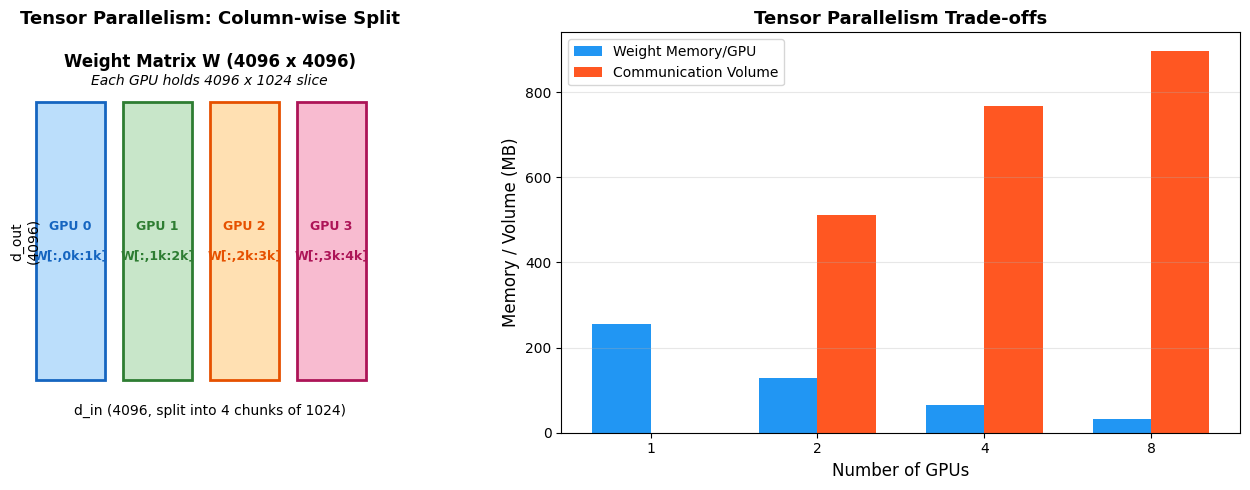

Pros: Reduces per-GPU memory for individual layers. Enables very large hidden dimensions.
Cons: Requires very fast inter-GPU communication (NVLink), since GPUs must communicate
      WITHIN each layer -- not just at the end of a step.
When to use: Individual layers are too large for one GPU. Always within a single node (NVLink).


In [6]:
# Visualize how a weight matrix is split
def visualize_tensor_parallelism():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Matrix splitting diagram
    ax = axes[0]
    num_gpus = 4
    colors = ['#BBDEFB', '#C8E6C9', '#FFE0B2', '#F8BBD0']
    gpu_colors = ['#1565C0', '#2E7D32', '#E65100', '#AD1457']

    # Draw the full weight matrix
    for i in range(num_gpus):
        rect = plt.Rectangle((i * 2.5, 0), 2, 8, facecolor=colors[i],
                            edgecolor=gpu_colors[i], linewidth=2)
        ax.add_patch(rect)
        ax.text(i * 2.5 + 1, 4, f'GPU {i}\n\nW[:,{i}k:{i+1}k]',
               ha='center', va='center', fontsize=9, fontweight='bold', color=gpu_colors[i])

    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1.5, 10)
    ax.set_title('Tensor Parallelism: Column-wise Split', fontsize=13, fontweight='bold')
    ax.text(5, 9, 'Weight Matrix W (4096 x 4096)', ha='center', fontsize=12, fontweight='bold')
    ax.text(5, 8.5, 'Each GPU holds 4096 x 1024 slice', ha='center', fontsize=10, style='italic')

    # Dimension labels
    ax.text(-0.3, 4, 'd_out\n(4096)', ha='center', va='center', fontsize=10, rotation=90)
    ax.text(5, -1, 'd_in (4096, split into 4 chunks of 1024)', ha='center', fontsize=10)

    ax.set_aspect('equal')
    ax.axis('off')

    # Right: Communication cost
    ax = axes[1]
    num_gpus_list = [1, 2, 4, 8]
    d_model = 4096
    batch_seq = 32 * 2048  # batch_size * seq_len

    # Per-GPU weight memory (MB)
    weight_per_gpu = [(d_model * d_model * 4 * 4) / g / 1024**2 for g in num_gpus_list]  # 4 weight matrices
    # Communication volume per step (all-reduce, MB)
    comm_volume = [batch_seq * d_model * 2 * 2 * (g-1)/g / 1024**2 if g > 1 else 0 for g in num_gpus_list]

    x_pos = np.arange(len(num_gpus_list))
    width = 0.35

    bars1 = ax.bar(x_pos - width/2, weight_per_gpu, width, label='Weight Memory/GPU', color='#2196F3')
    bars2 = ax.bar(x_pos + width/2, comm_volume, width, label='Communication Volume', color='#FF5722')

    ax.set_xlabel('Number of GPUs', fontsize=12)
    ax.set_ylabel('Memory / Volume (MB)', fontsize=12)
    ax.set_title('Tensor Parallelism Trade-offs', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(num_gpus_list)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

visualize_tensor_parallelism()

print("Pros: Reduces per-GPU memory for individual layers. Enables very large hidden dimensions.")
print("Cons: Requires very fast inter-GPU communication (NVLink), since GPUs must communicate")
print("      WITHIN each layer -- not just at the end of a step.")
print("When to use: Individual layers are too large for one GPU. Always within a single node (NVLink).")

## Strategy 3: Pipeline Parallelism

**Core idea:** Assign different layers of the model to different GPUs. Data flows through the pipeline.

### How it works:
1. Split the model into stages (groups of consecutive layers)
2. Each stage runs on a different GPU
3. GPU 0 processes micro-batch 1, passes output to GPU 1
4. While GPU 1 processes micro-batch 1, GPU 0 starts on micro-batch 2
5. This creates a pipeline where all GPUs can work concurrently

In [ ]:
#@title 🎧 Code Walkthrough: Pipeline Parallelism Code
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_09_pipeline_parallelism_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [7]:
def simulate_pipeline_parallelism(n_layers=8, num_gpus=4, num_microbatches=8):
    """
    Simulate pipeline parallelism by splitting layers across 'GPUs'
    and processing micro-batches in a pipeline fashion.
    """
    torch.manual_seed(42)
    d = 256

    # Create layers and split into stages
    layers = nn.ModuleList([nn.Linear(d, d) for _ in range(n_layers)]).to(device)
    layers_per_gpu = n_layers // num_gpus

    stages = []
    for g in range(num_gpus):
        start = g * layers_per_gpu
        end = start + layers_per_gpu
        stages.append(layers[start:end])
        print(f"  GPU {g}: Layers {start}-{end-1} ({layers_per_gpu} layers)")

    # Create micro-batches
    batch = torch.randn(num_microbatches * 4, d, device=device)
    microbatches = batch.chunk(num_microbatches)

    print(f"\n  Total micro-batches: {num_microbatches}")
    print(f"  Micro-batch size: {microbatches[0].shape[0]}")

    # Simulate pipeline execution (tracking which GPU is busy at each "timestep")
    # In real pipeline parallelism, this happens asynchronously
    schedule = []
    outputs = []

    # Forward pass through pipeline
    for mb_idx, mb in enumerate(microbatches):
        x = mb
        for stage_idx, stage in enumerate(stages):
            for layer in stage:
                x = torch.relu(layer(x))
            schedule.append((mb_idx, stage_idx, 'fwd'))
        outputs.append(x)

    print(f"\n  All {num_microbatches} micro-batches processed through {num_gpus} stages.")
    print(f"  Output shape per micro-batch: {outputs[0].shape}")

    # Memory savings
    total_params = sum(p.numel() for p in layers.parameters())
    params_per_gpu = total_params // num_gpus
    print(f"\n  Total parameters: {total_params:,}")
    print(f"  Parameters per GPU: {params_per_gpu:,} ({num_gpus}x reduction)")

    return schedule


print("Simulating Pipeline Parallelism:")
print("=" * 60)
schedule = simulate_pipeline_parallelism()

Simulating Pipeline Parallelism:
  GPU 0: Layers 0-1 (2 layers)
  GPU 1: Layers 2-3 (2 layers)
  GPU 2: Layers 4-5 (2 layers)
  GPU 3: Layers 6-7 (2 layers)

  Total micro-batches: 8
  Micro-batch size: 4

  All 8 micro-batches processed through 4 stages.
  Output shape per micro-batch: torch.Size([4, 256])

  Total parameters: 526,336
  Parameters per GPU: 131,584 (4x reduction)


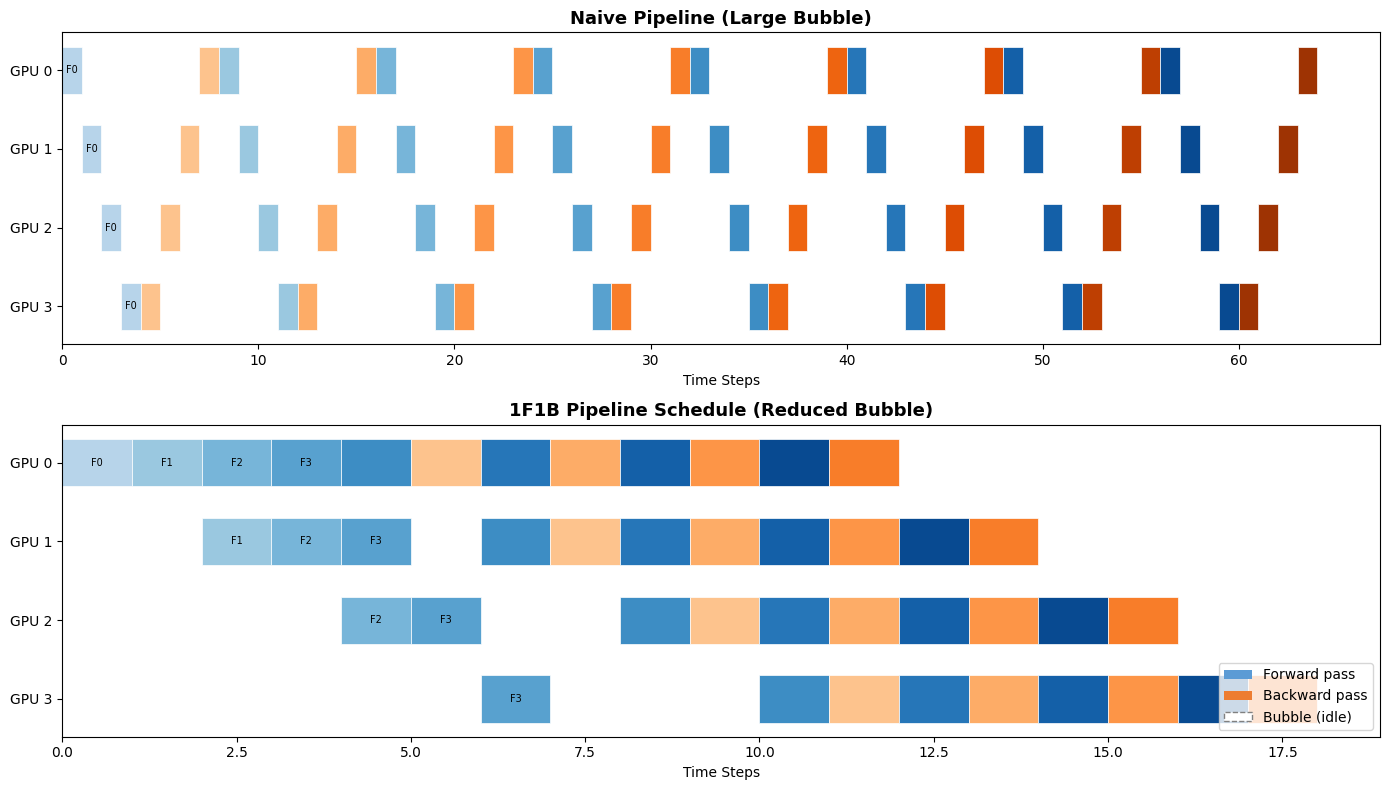

Pros: Each GPU only holds a fraction of the model layers. Communication is minimal
      (only between adjacent stages).
Cons: Pipeline bubble -- GPUs are idle at the start and end of each batch.
      Bubble fraction = (p-1) / (p-1+m) where p=stages, m=micro-batches.
When to use: Model has many layers, combined with tensor/data parallelism.


In [8]:
# Visualize pipeline schedule and bubble
def visualize_pipeline_schedule():
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    num_gpus = 4
    num_microbatches = 8
    colors_fwd = plt.cm.Blues(np.linspace(0.3, 0.9, num_microbatches))
    colors_bwd = plt.cm.Oranges(np.linspace(0.3, 0.9, num_microbatches))

    # Top: Naive schedule (one micro-batch at a time)
    ax = axes[0]
    ax.set_title('Naive Pipeline (Large Bubble)', fontsize=13, fontweight='bold')

    for mb in range(num_microbatches):
        for g in range(num_gpus):
            t_start = mb * (2 * num_gpus) + g
            ax.barh(g, 1, left=t_start, height=0.6, color=colors_fwd[mb], edgecolor='white', linewidth=0.5)
            if mb == 0:
                ax.text(t_start + 0.5, g, f'F{mb}', ha='center', va='center', fontsize=7)

        for g in range(num_gpus - 1, -1, -1):
            t_start = mb * (2 * num_gpus) + num_gpus + (num_gpus - 1 - g)
            ax.barh(g, 1, left=t_start, height=0.6, color=colors_bwd[mb], edgecolor='white', linewidth=0.5)

    ax.set_yticks(range(num_gpus))
    ax.set_yticklabels([f'GPU {i}' for i in range(num_gpus)])
    ax.set_xlabel('Time Steps')
    ax.invert_yaxis()

    # Bottom: 1F1B schedule (interleaved)
    ax = axes[1]
    ax.set_title('1F1B Pipeline Schedule (Reduced Bubble)', fontsize=13, fontweight='bold')

    # Simplified 1F1B visualization
    # Warmup: forward passes fill the pipeline
    t = 0
    for mb in range(num_gpus):  # warmup micro-batches
        for g in range(min(mb + 1, num_gpus)):
            t_start = mb + g
            ax.barh(g, 1, left=t_start, height=0.6, color=colors_fwd[mb], edgecolor='white', linewidth=0.5)
            ax.text(t_start + 0.5, g, f'F{mb}', ha='center', va='center', fontsize=7)

    # Steady state: alternating forward and backward
    offset = num_gpus
    for mb in range(num_gpus, num_microbatches):
        for g in range(num_gpus):
            t_fwd = offset + (mb - num_gpus) * 2 + g * 2
            ax.barh(g, 1, left=t_fwd, height=0.6, color=colors_fwd[mb], edgecolor='white', linewidth=0.5)
            t_bwd = t_fwd + 1
            bwd_mb = mb - num_gpus
            if bwd_mb >= 0:
                ax.barh(g, 1, left=t_bwd, height=0.6, color=colors_bwd[bwd_mb], edgecolor='white', linewidth=0.5)

    ax.set_yticks(range(num_gpus))
    ax.set_yticklabels([f'GPU {i}' for i in range(num_gpus)])
    ax.set_xlabel('Time Steps')
    ax.invert_yaxis()

    # Legend
    fwd_patch = mpatches.Patch(facecolor='#5B9BD5', label='Forward pass')
    bwd_patch = mpatches.Patch(facecolor='#ED7D31', label='Backward pass')
    bubble_patch = mpatches.Patch(facecolor='white', edgecolor='gray', label='Bubble (idle)', linestyle='--')
    ax.legend(handles=[fwd_patch, bwd_patch, bubble_patch], loc='lower right', fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_pipeline_schedule()

print("Pros: Each GPU only holds a fraction of the model layers. Communication is minimal")
print("      (only between adjacent stages).")
print("Cons: Pipeline bubble -- GPUs are idle at the start and end of each batch.")
print("      Bubble fraction = (p-1) / (p-1+m) where p=stages, m=micro-batches.")
print("When to use: Model has many layers, combined with tensor/data parallelism.")

In [ ]:
#@title 🎧 Listen: Sequence Parallelism Concept
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_11_sequence_parallelism_concept.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Strategy 4: Sequence Parallelism

**Core idea:** Split the sequence dimension across GPUs. Each GPU handles a chunk of the token sequence.

This is critical for long-context models (32K, 128K tokens) where the attention matrix alone can exceed GPU memory.

In [ ]:
#@title 🎧 Code Walkthrough: Sequence Parallelism Code
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_12_sequence_parallelism_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
def demonstrate_attention_memory_scaling():
    """
    Show how attention memory scales quadratically with sequence length,
    motivating the need for sequence parallelism.
    """
    n_heads = 32
    batch_size = 1

    seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
    attn_memory_gb = []

    for seq_len in seq_lengths:
        # Attention score matrix: (batch, heads, seq, seq) in FP16
        mem_bytes = batch_size * n_heads * seq_len * seq_len * 2  # 2 bytes per FP16
        mem_gb = mem_bytes / (1024**3)
        attn_memory_gb.append(mem_gb)

    print(f"Attention Score Memory (batch=1, heads=32, FP16):")
    print(f"{'Seq Length':>12} {'Memory':>12} {'Fits in T4 (16GB)?':>20} {'Fits in A100 (80GB)?':>22}")
    print("=" * 70)
    for sl, mem in zip(seq_lengths, attn_memory_gb):
        t4 = 'Yes' if mem < 16 else 'NO'
        a100 = 'Yes' if mem < 80 else 'NO'
        print(f"{sl:>12,} {mem:>10.2f} GB {t4:>20} {a100:>22}")

    return seq_lengths, attn_memory_gb


seq_lengths, attn_mem = demonstrate_attention_memory_scaling()

In [ ]:
#@title 🎧 What to Look For: Sequence Parallelism Vis
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_13_sequence_parallelism_vis.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
# Visualize attention memory scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Quadratic memory growth
ax = axes[0]
ax.semilogy(seq_lengths, attn_mem, 'o-', color='#9C27B0', linewidth=2, markersize=8)
ax.axhline(y=16, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='T4 limit (16 GB)')
ax.axhline(y=80, color='darkred', linestyle='--', alpha=0.7, linewidth=1.5, label='A100 limit (80 GB)')
ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Attention Memory (GB)', fontsize=12)
ax.set_title('Attention Memory vs Sequence Length\n(quadratic scaling: O(n^2))', fontsize=13, fontweight='bold')
ax.set_xscale('log', base=2)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: How sequence parallelism helps
ax = axes[1]
seq_len = 32768
num_gpus_list = [1, 2, 4, 8, 16]
n_heads = 32

mem_per_gpu = []
for ng in num_gpus_list:
    # With sequence parallelism, each GPU handles seq_len/ng tokens
    # But attention still needs to see all tokens (ring attention)
    # Peak memory per GPU: batch * heads * (seq/ng) * seq * 2 bytes
    local_seq = seq_len // ng
    mem = 1 * n_heads * local_seq * seq_len * 2 / (1024**3)
    mem_per_gpu.append(mem)

ax.bar(range(len(num_gpus_list)), mem_per_gpu, color='#9C27B0', alpha=0.8)
ax.axhline(y=80, color='darkred', linestyle='--', alpha=0.7, linewidth=1.5, label='A100 limit (80 GB)')
ax.set_xlabel('Number of GPUs', fontsize=12)
ax.set_ylabel('Peak Memory per GPU (GB)', fontsize=12)
ax.set_title(f'Sequence Parallelism\n(seq_len={seq_len:,}, 32 heads)', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(num_gpus_list)))
ax.set_xticklabels(num_gpus_list)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(mem_per_gpu):
    color = 'red' if v > 80 else 'green'
    ax.text(i, v + 1, f'{v:.1f} GB', ha='center', fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print("Pros: Enables training with very long context windows (32K, 128K+ tokens).")
print("Cons: Attention needs all tokens to see all other tokens, requiring careful")
print("      communication patterns (ring attention, context parallelism).")
print("When to use: Long sequence lengths where attention memory exceeds GPU capacity.")

In [ ]:
#@title 🎧 Listen: Expert Parallelism Concept
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_14_expert_parallelism_concept.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Strategy 5: Expert Parallelism

**Core idea:** For Mixture-of-Experts (MoE) models, place different experts on different GPUs. Each token only visits a few experts.

Models like Mixtral (8 experts, top-2 routing) and DeepSeek-V3 (256 experts, top-8 routing) use this strategy.

In [ ]:
#@title 🎧 Code Walkthrough: Expert Parallelism Code
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_15_expert_parallelism_code.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
def simulate_expert_parallelism(d_model=256, num_experts=8, top_k=2, num_gpus=4):
    """
    Simulate a simplified Mixture-of-Experts layer with expert parallelism.
    """
    torch.manual_seed(42)
    batch_size = 4
    seq_len = 16
    d_ff = d_model * 4

    # Create experts (simple FFN layers)
    experts = nn.ModuleList([
        nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        for _ in range(num_experts)
    ]).to(device)

    # Router: learns which experts to send each token to
    router = nn.Linear(d_model, num_experts, bias=False).to(device)

    # Input tokens
    x = torch.randn(batch_size, seq_len, d_model, device=device)
    tokens = x.view(-1, d_model)  # (batch*seq, d_model)

    # Routing: compute scores and select top-k experts per token
    router_logits = router(tokens)  # (batch*seq, num_experts)
    router_probs = torch.softmax(router_logits, dim=-1)
    top_k_probs, top_k_indices = router_probs.topk(top_k, dim=-1)

    print(f"  Model: {num_experts} experts, top-{top_k} routing")
    print(f"  Input: {batch_size} x {seq_len} = {batch_size * seq_len} tokens")
    print(f"  Expert distribution: {num_gpus} GPUs, {num_experts // num_gpus} experts per GPU")
    print()

    # Count tokens per expert
    expert_counts = torch.zeros(num_experts, dtype=torch.long)
    for i in range(num_experts):
        expert_counts[i] = (top_k_indices == i).sum().item()

    experts_per_gpu = num_experts // num_gpus
    for g in range(num_gpus):
        start_exp = g * experts_per_gpu
        end_exp = start_exp + experts_per_gpu
        gpu_tokens = expert_counts[start_exp:end_exp].sum().item()
        print(f"  GPU {g} (Experts {start_exp}-{end_exp-1}): processes {gpu_tokens} token-expert pairs")
        for e in range(start_exp, end_exp):
            print(f"    Expert {e}: {expert_counts[e].item()} tokens")

    # Show load imbalance
    gpu_loads = [expert_counts[g*experts_per_gpu:(g+1)*experts_per_gpu].sum().item()
                for g in range(num_gpus)]
    avg_load = np.mean(gpu_loads)
    max_load = max(gpu_loads)
    print(f"\n  Load balance: avg={avg_load:.0f}, max={max_load:.0f}, imbalance={max_load/avg_load:.2f}x")

    # Memory comparison
    total_expert_params = sum(p.numel() for p in experts.parameters())
    per_gpu_params = total_expert_params // num_gpus
    active_params = total_expert_params * top_k / num_experts
    print(f"\n  Total expert parameters: {total_expert_params:,}")
    print(f"  Parameters per GPU: {per_gpu_params:,}")
    print(f"  Active parameters per token: {int(active_params):,} ({top_k}/{num_experts} = {top_k/num_experts:.0%})")

    return expert_counts


print("Simulating Expert Parallelism (Mixtral-style MoE):")
print("=" * 60)
expert_counts = simulate_expert_parallelism()

In [ ]:
#@title 🎧 What to Look For: Expert Parallelism Vis
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_16_expert_parallelism_vis.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
# Visualize expert utilization and load balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Expert token distribution
ax = axes[0]
colors = ['#BBDEFB']*2 + ['#C8E6C9']*2 + ['#FFE0B2']*2 + ['#F8BBD0']*2
edge_colors = ['#1565C0']*2 + ['#2E7D32']*2 + ['#E65100']*2 + ['#AD1457']*2

bars = ax.bar(range(8), expert_counts.numpy(), color=colors, edgecolor=edge_colors, linewidth=2)
ax.set_xlabel('Expert Index', fontsize=12)
ax.set_ylabel('Tokens Routed', fontsize=12)
ax.set_title('Token Distribution Across Experts\n(Colors = GPUs)', fontsize=13, fontweight='bold')
ax.axhline(y=expert_counts.float().mean().item(), color='red', linestyle='--', alpha=0.7, label='Average')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# GPU labels
for g in range(4):
    ax.text(g*2 + 0.5, -3, f'GPU {g}', ha='center', fontsize=10, fontweight='bold',
           color=edge_colors[g*2])

# Right: MoE efficiency comparison
ax = axes[1]
model_sizes = ['Dense 7B', 'MoE 47B\n(8 experts)', 'Dense 13B', 'MoE 141B\n(16 experts)']
total_params = [7, 47, 13, 141]
active_params = [7, 13, 13, 22]
x_pos = np.arange(len(model_sizes))
width = 0.35

bars1 = ax.bar(x_pos - width/2, total_params, width, label='Total Parameters (B)', color='#E3F2FD', edgecolor='#1565C0', linewidth=2)
bars2 = ax.bar(x_pos + width/2, active_params, width, label='Active Parameters (B)', color='#4CAF50', edgecolor='#2E7D32', linewidth=2)

ax.set_ylabel('Parameters (Billions)', fontsize=12)
ax.set_title('MoE Efficiency: Total vs Active Parameters', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_sizes, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Pros: Massive model capacity without proportional compute cost.")
print("      A 47B MoE model uses similar compute per token as a 13B dense model.")
print("Cons: Load imbalance (some experts get more tokens), routing overhead,")
print("      all-to-all communication between GPUs.")
print("When to use: You want more model capacity without proportionally more compute.")

In [ ]:
#@title 🎧 Transition: Compare Strategies Intro
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_17_compare_strategies_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Comparing All Five Strategies

Let us put everything together in a comparison table and visualization.

In [ ]:
#@title 🎧 What to Look For: Compare Strategies Table Vis
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_18_compare_strategies_table_vis.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
# Summary comparison
strategies = {
    'Data\nParallelism': {
        'what_split': 'Training data',
        'memory_saved': 'None (weights)',
        'communication': 'All-reduce\n(gradients)',
        'comm_volume': 'Medium',
        'implementation': 'Easy',
        'color': '#2196F3',
    },
    'Tensor\nParallelism': {
        'what_split': 'Weight matrices',
        'memory_saved': 'Weights + activations',
        'communication': 'All-reduce /\nAll-gather per layer',
        'comm_volume': 'High',
        'implementation': 'Hard',
        'color': '#4CAF50',
    },
    'Pipeline\nParallelism': {
        'what_split': 'Model layers',
        'memory_saved': 'Weights + optimizer',
        'communication': 'Point-to-point\n(between stages)',
        'comm_volume': 'Low',
        'implementation': 'Medium',
        'color': '#FF9800',
    },
    'Sequence\nParallelism': {
        'what_split': 'Token sequence',
        'memory_saved': 'Activations',
        'communication': 'Ring attention /\nAll-to-all',
        'comm_volume': 'High',
        'implementation': 'Hard',
        'color': '#9C27B0',
    },
    'Expert\nParallelism': {
        'what_split': 'MoE experts',
        'memory_saved': 'Expert weights',
        'communication': 'All-to-all\n(token routing)',
        'comm_volume': 'Medium',
        'implementation': 'Hard',
        'color': '#E91E63',
    },
}

print(f"{'Strategy':<18} {'What is Split':<18} {'Memory Saved':<22} {'Communication':<22} {'Difficulty':<12}")
print("=" * 95)
for name, info in strategies.items():
    name_clean = name.replace('\n', ' ')
    print(f"{name_clean:<18} {info['what_split']:<18} {info['memory_saved']:<22} {info['communication'].replace(chr(10), ', '):<22} {info['implementation']:<12}")

In [ ]:
# Visualization: When to use each strategy
fig, ax = plt.subplots(figsize=(14, 7))

# Create a decision matrix
situations = [
    'Model fits on 1 GPU,\nwant faster training',
    'Model weights too\nlarge for 1 GPU',
    'Model has too many\nlayers for 1 GPU',
    'Very long sequences\n(32K+ tokens)',
    'MoE model with\nmany experts',
    'Training GPT-3 scale\n(175B+ params)',
]

strategy_names = ['Data P.', 'Tensor P.', 'Pipeline P.', 'Sequence P.', 'Expert P.']
strategy_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

# Applicability matrix (0=not useful, 1=useful, 2=essential)
matrix = np.array([
    [2, 0, 0, 0, 0],  # Model fits, want speed
    [0, 2, 1, 0, 0],  # Weights too large
    [0, 0, 2, 0, 0],  # Too many layers
    [0, 0, 0, 2, 0],  # Long sequences
    [1, 0, 0, 0, 2],  # MoE model
    [2, 2, 2, 1, 1],  # GPT-3 scale
])

cmap = plt.cm.RdYlGn
im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=-0.5, vmax=2.5)

ax.set_xticks(range(len(strategy_names)))
ax.set_xticklabels(strategy_names, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(situations)))
ax.set_yticklabels(situations, fontsize=10)
ax.set_title('When to Use Each Parallelism Strategy', fontsize=14, fontweight='bold', pad=15)

# Add text annotations
labels = {0: 'Not\nneeded', 1: 'Useful', 2: 'Essential'}
for i in range(len(situations)):
    for j in range(len(strategy_names)):
        text = labels[matrix[i, j]]
        color = 'white' if matrix[i, j] == 0 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=9, color=color, fontweight='bold')

plt.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.6).set_ticklabels(['Not needed', 'Useful', 'Essential'])

plt.tight_layout()
plt.show()

print("\nKey Insight: Large-scale training (GPT-3, LLaMA, etc.) uses MULTIPLE strategies")
print("simultaneously. This is called 3D or 5D parallelism:")
print("  - Tensor parallelism within a node (8 GPUs on NVLink)")
print("  - Pipeline parallelism across nodes")
print("  - Data parallelism across groups of nodes")
print("  - Sequence parallelism for long-context training")
print("  - Expert parallelism for MoE models")

In [ ]:
#@title 🎧 Narration: Todo1 Intro
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_19_todo1_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Exercises

### TODO Exercise 1: Implement Row-Parallel Tensor Parallelism

In the main text, we showed column-parallel splitting. Now implement **row-parallel** splitting, where the weight matrix is split along the input dimension instead.

For a linear layer y = x @ W^T:
- Column-parallel: split W along rows (output dim) -> concatenate results
- Row-parallel: split W along columns (input dim) -> each GPU gets a slice of x, results are summed

In [ ]:
#@title 🎧 Before You Start: Todo1
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_20_todo1.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
# TODO Exercise 1: Implement row-parallel tensor parallelism
#
# Steps:
# 1. Create a weight matrix W of shape (d_out, d_in)
# 2. Split W along columns: W_0 = W[:, :d_in//N], W_1 = W[:, d_in//N:2*d_in//N], ...
# 3. Split input x correspondingly: x_0 = x[:, :d_in//N], ...
# 4. Each "GPU" computes: y_i = x_i @ W_i^T
# 5. All-reduce (sum) the partial results: y = y_0 + y_1 + ... + y_{N-1}
# 6. Verify this matches the full computation: y = x @ W^T

d_in = 512
d_out = 512
num_gpus = 4

# TODO: Your implementation here
# W = torch.randn(d_out, d_in, device=device)
# x = torch.randn(8, d_in, device=device)
# y_full = x @ W.T

# Split and compute partial results
# ...

# All-reduce (sum)
# y_reconstructed = sum(partial_results)

# Verify
# max_diff = (y_full - y_reconstructed).abs().max().item()
# print(f"Max difference: {max_diff:.2e}")

In [ ]:
#@title 🎧 Narration: Todo2 Intro
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_21_todo2_intro.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


### TODO Exercise 2: Calculate Pipeline Bubble Fraction

The pipeline bubble is the fraction of time GPUs are idle. For a pipeline with `p` stages and `m` micro-batches:

- Bubble fraction = (p - 1) / (p - 1 + m)

Calculate and plot the bubble fraction for different values of p and m. What ratio of m/p keeps the bubble under 5%?

In [ ]:
#@title 🎧 Before You Start: Todo2
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_22_todo2.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


In [ ]:
# TODO Exercise 2: Pipeline bubble analysis
#
# Steps:
# 1. For p in [2, 4, 8, 16], calculate bubble fraction for m in [1, 2, 4, 8, 16, 32, 64]
# 2. Plot bubble fraction vs number of micro-batches for each p
# 3. Find the minimum m/p ratio that keeps bubble < 5%

stages_list = [2, 4, 8, 16]
microbatch_list = [1, 2, 4, 8, 16, 32, 64, 128]

# TODO: Calculate bubble fractions
# for p in stages_list:
#     bubbles = [(p-1) / (p-1+m) for m in microbatch_list]
#     ...

# TODO: Plot results
# ...

# TODO: Find minimum m/p for <5% bubble
# ...

In [ ]:
#@title 🎧 Wrap-Up: Closing
from IPython.display import Audio, display
import os as _os
_f = "/content/narration/03_23_closing.mp3"
if _os.path.exists(_f):
    display(Audio(_f))
else:
    print("Run the first cell to download narration audio.")


## Summary

In this notebook, we have explored all five parallelism strategies:

| Strategy | Splits | Key Benefit | Key Cost |
|---|---|---|---|
| **Data Parallelism** | Training data | Simple, good scaling | Requires full model per GPU |
| **Tensor Parallelism** | Weight matrices | Splits individual layers | Needs fast NVLink |
| **Pipeline Parallelism** | Model layers | Low communication | Pipeline bubble |
| **Sequence Parallelism** | Token sequence | Enables long contexts | Complex attention handling |
| **Expert Parallelism** | MoE experts | Scales capacity cheaply | Load balancing |

### The Big Picture

Modern large-scale training combines multiple strategies:
- **Within a node** (8 GPUs on NVLink): Tensor parallelism
- **Across nodes**: Pipeline parallelism + Data parallelism
- **For long contexts**: Sequence parallelism
- **For MoE models**: Expert parallelism

In the remaining pods of this course, we will dive deep into each strategy, implementing them from scratch and understanding the mathematics, communication patterns, and optimization techniques that make them work efficiently.

### What's Next

Pod 2 will focus on **GPU Memory Components** -- understanding exactly where memory goes during training (weights, gradients, optimizer states, activations) and how to profile and measure each one. This foundational understanding is essential before implementing any parallelism strategy.